<a href="https://colab.research.google.com/github/tommystarrrrrrr/2025_Kecerdasan-Buatan/blob/main/Supervise_Learning_Regression_dan_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervise Learning Regression dan Classification

### 1. Decision Tree

In [77]:
import pandas as pd
iris = pd.read_csv('Iris.csv')
iris.info()
iris.head()
iris.drop('Id',axis=1,inplace=True)
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm' ]]
y = iris['Species']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=123)
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier()

tree_model = tree_model.fit(X_train, y_train)
from sklearn.metrics import accuracy_score

y_pred = tree_model.predict(X_test)

acc_secore = round(accuracy_score(y_pred, y_test), 3)

print('Accuracy: ', acc_secore)
print(tree_model.predict([[6.2, 3.4, 5.4, 2.3]])[0])
from sklearn.tree import export_graphviz
export_graphviz(
    tree_model,
    out_file = "iris_tree.dot",
    feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
    class_names = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica' ],
    rounded= True,
    filled =True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
Accuracy:  0.933
Iris-virginica


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### 2. Linear Regression

Jumlah kamar: 6
Prediksi harga kamar: 102110.16949152542

Jumlah kamar: 7
Prediksi harga kamar: 119542.37288135593



1.0

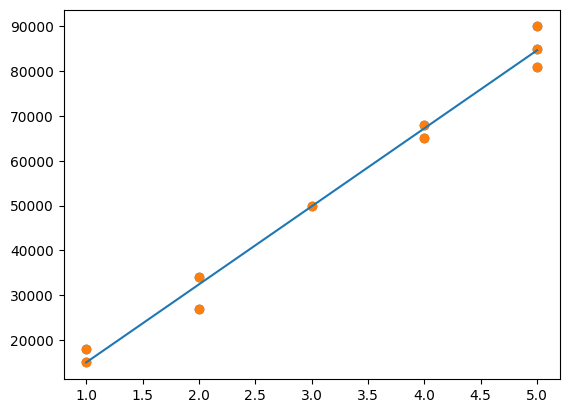

In [76]:
import numpy as np

bedrooms = np.array([1,1,2,2,3,4,4,5,5,5])
house_price = np.array([15000, 18000, 27000, 34000, 50000, 68000, 65000, 81000,85000, 90000])
import matplotlib.pyplot as plt
%matplotlib inline
plt.scatter(bedrooms, house_price)
from sklearn.linear_model import LinearRegression
bedrooms = bedrooms.reshape(-1, 1)
linreg = LinearRegression()
linreg.fit(bedrooms, house_price)
plt.scatter(bedrooms, house_price)
plt.plot(bedrooms, linreg.predict(bedrooms))

X_test = np.array([[6], [7]])
y_pred = linreg.predict(X_test)

for i in range(len(X_test)):
    print("Jumlah kamar:", X_test[i][0])
    print("Prediksi harga kamar:", y_pred[i])
    print()
linreg.score(X_test, y_pred)


### 3. Logistic Regression

In [78]:
import pandas as pd

df = pd.read_csv('Social_Network_Ads.csv')
df.head()
df.head()

data = df.drop(columns=['User ID'])

data = pd.get_dummies(data)
data

predictions = ['Age' , 'EstimatedSalary' , 'Gender_Female' , 'Gender_Male']
X = data[predictions]
y = data['Purchased']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
scaled_data = scaler.transform(X)
scaled_data = pd.DataFrame(scaled_data, columns= X.columns)
scaled_data.head()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(scaled_data, y, test_size=0.2, random_state=1)
from sklearn import linear_model

model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.825

# TUGAS PRAKTIKUM

### 1.  Model Machine Learning untuk Memprediksi Transaksi Calon Konsumen

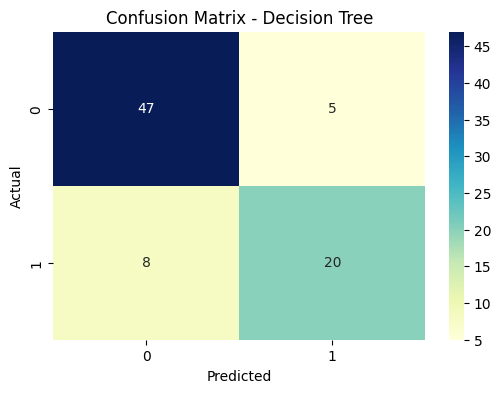

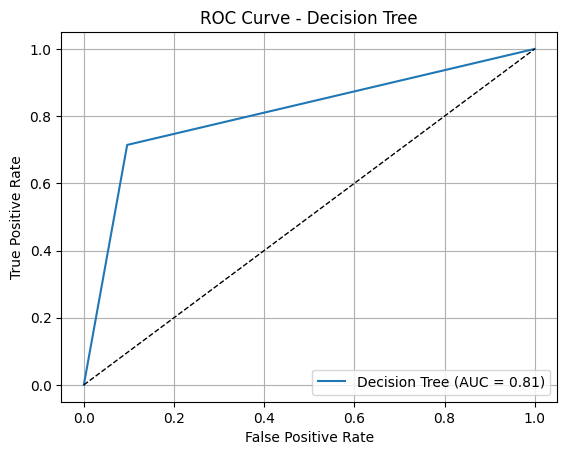

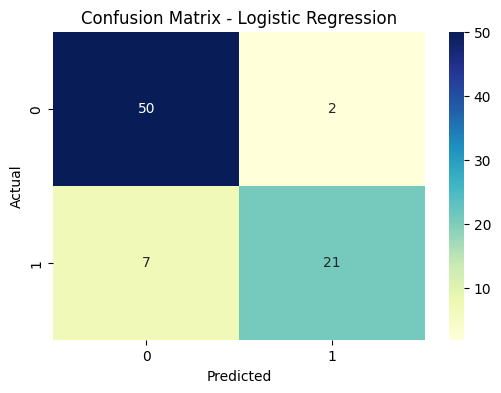

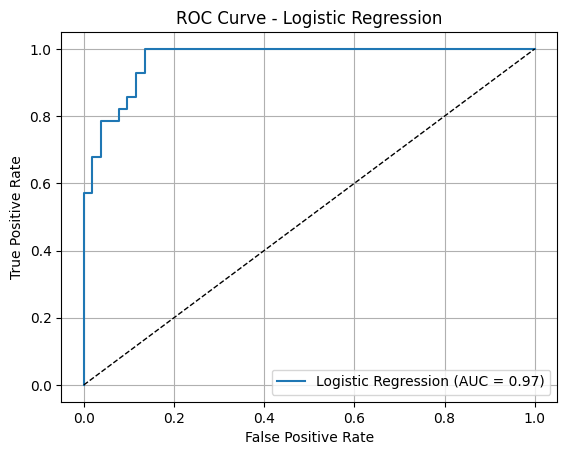


 Perbandingan Skor Model:



,Accuracy,Precision,Recall,F1
Decision Tree,0.837500,0.800000,0.714286,0.754717
Logistic Regression,0.887500,0.913043,0.750000,0.823529


<ipython-input-79-57b4d9ccae57>:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, y='Feature', x='Importance', palette='crest')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


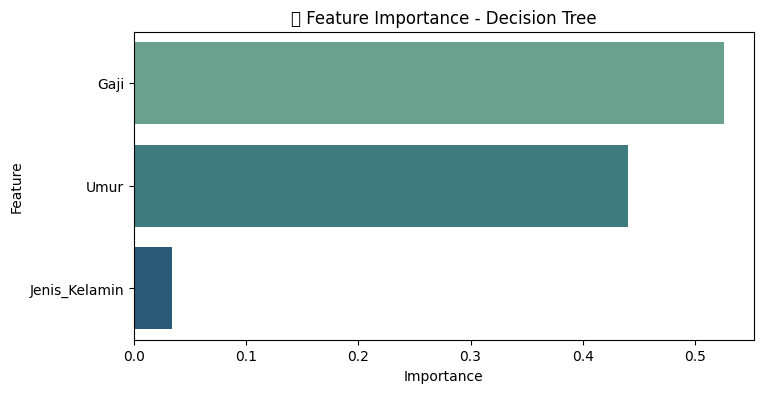

In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('iklan_sosmed.csv', sep=';')

data = data.drop('ID', axis=1)

data['Jenis_Kelamin'] = LabelEncoder().fit_transform(data['Jenis_Kelamin'])

X = data[['Jenis_Kelamin', 'Umur', 'Gaji']]
y = data['Transaksi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train[['Umur', 'Gaji']] = scaler.fit_transform(X_train[['Umur', 'Gaji']])
X_test[['Umur', 'Gaji']] = scaler.transform(X_test[['Umur', 'Gaji']])

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1
    }

    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

print("\n Perbandingan Skor Model:\n")
comparison = pd.DataFrame(results).T
display(comparison.style.background_gradient(cmap='YlOrBr'))

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models["Decision Tree"].feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance, y='Feature', x='Importance', palette='crest')
plt.title('🔍 Feature Importance - Decision Tree')
plt.show()


### 2. Algoritma Linear Regression untuk memprediksi gaji pegawai

Kolom: ['Tahun_Pengalaman', 'Gaji']
 Mean Absolute Error (MAE): Rp 94,296,807.46
 Mean Squared Error (MSE): Rp 11,211,771,792,579,374.00
 Root Mean Squared Error (RMSE): Rp 105,885,654.33
 Koefisien Determinasi (R²): 90.24%

 Persamaan Regresi: Gaji = 379,823,745.18 + (141,357,229.85 × Tahun Pengalaman)


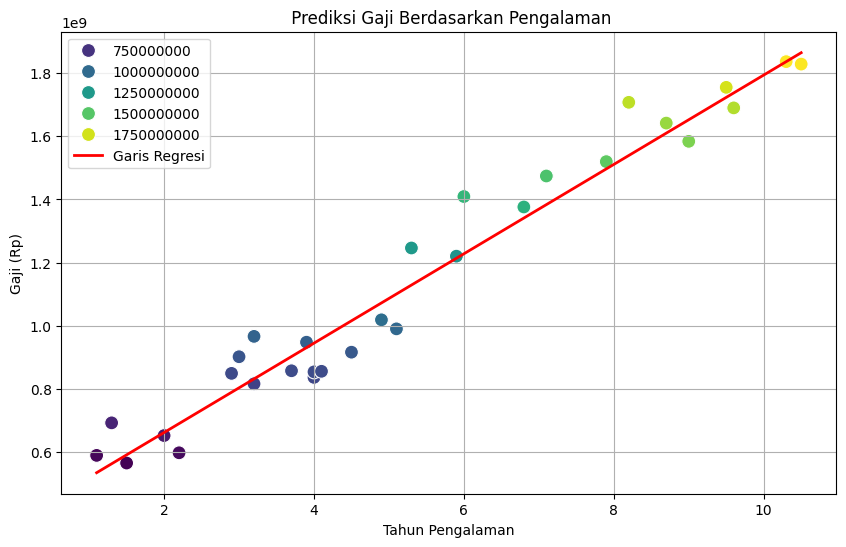


 Prediksi Gaji untuk Beberapa Tahun Pengalaman:
-  0 tahun → Rp 379,823,745.18
-  2 tahun → Rp 662,538,204.87
-  5 tahun → Rp 1,086,609,894.40
- 10 tahun → Rp 1,793,396,043.63
- 15 tahun → Rp 2,500,182,192.86


In [80]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Data_Gaji.csv', sep=';')

print("Kolom:", data.columns.tolist())

X = data[['Tahun_Pengalaman']].values
y = data['Gaji'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f" Mean Absolute Error (MAE): Rp {mae:,.2f}")
print(f" Mean Squared Error (MSE): Rp {mse:,.2f}")
print(f" Root Mean Squared Error (RMSE): Rp {rmse:,.2f}")
print(f" Koefisien Determinasi (R²): {r2:.2%}")

intercept = model.intercept_
slope = model.coef_[0]
print(f"\n Persamaan Regresi: Gaji = {intercept:,.2f} + ({slope:,.2f} × Tahun Pengalaman)")

plt.figure(figsize=(10, 6))
palette = sns.color_palette("coolwarm", as_cmap=True)
sns.scatterplot(x=data['Tahun_Pengalaman'], y=data['Gaji'], hue=data['Gaji'], palette='viridis', s=100)
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Garis Regresi')
plt.xlabel('Tahun Pengalaman')
plt.ylabel('Gaji (Rp)')
plt.title(' Prediksi Gaji Berdasarkan Pengalaman')
plt.legend()
plt.grid(True)
plt.show()

contoh_pengalaman = np.array([[0], [2], [5], [10], [15]])
prediksi_batch = model.predict(contoh_pengalaman)

print("\n Prediksi Gaji untuk Beberapa Tahun Pengalaman:")
for thn, gaji in zip(contoh_pengalaman.flatten(), prediksi_batch):
    print(f"- {thn:2d} tahun → Rp {gaji:,.2f}")

### 4. Parameter tunning pada masing-masing algoritma untuk meningkatkan akurasi

In [81]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dataset = pd.read_csv('iklan_sosmed.csv', delimiter=';')

X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("--- Parameter Tuning for Decision Tree ---")

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid_dt, scoring='accuracy', cv=10, n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

print(f"Best Parameters (Decision Tree): {grid_search_dt.best_params_}")
print(f"Best Accuracy Score (Decision Tree - CV): {grid_search_dt.best_score_:.4f}")

best_classifier_dt = grid_search_dt.best_estimator_
accuracy_dt_tuned = accuracy_score(y_test, best_classifier_dt.predict(X_test))
print(f"Akurasi Decision Tree (Tuned - Test Set): {accuracy_dt_tuned:.4f}")


print("\n--- Parameter Tuning for Logistic Regression ---")

param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

grid_search_lr = GridSearchCV(LogisticRegression(random_state=0, max_iter=200), param_grid_lr, scoring='accuracy', cv=10, n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

print(f"Best Parameters (Logistic Regression): {grid_search_lr.best_params_}")
print(f"Best Accuracy Score (Logistic Regression - CV): {grid_search_lr.best_score_:.4f}")

best_classifier_lr = grid_search_lr.best_estimator_
accuracy_lr_tuned = accuracy_score(y_test, best_classifier_lr.predict(X_test))
print(f"Akurasi Logistic Regression (Tuned - Test Set): {accuracy_lr_tuned:.4f}")

print("\n--- Perbandingan Akurasi Setelah Tuning ---")
print(f"Akurasi Decision Tree (Tuned): {accuracy_dt_tuned:.4f}")
print(f"Akurasi Logistic Regression (Tuned): {accuracy_lr_tuned:.4f}")

if accuracy_dt_tuned > accuracy_lr_tuned:
    print("Setelah tuning, Decision Tree memiliki akurasi yang lebih tinggi.")
elif accuracy_lr_tuned > accuracy_dt_tuned:
    print("Setelah tuning, Logistic Regression memiliki akurasi yang lebih tinggi.")
else:
    print("Setelah tuning, kedua algoritma memiliki akurasi yang sama.")

--- Parameter Tuning for Decision Tree ---
Best Parameters (Decision Tree): {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Accuracy Score (Decision Tree - CV): 0.8900
Akurasi Decision Tree (Tuned - Test Set): 0.9400

--- Parameter Tuning for Logistic Regression ---
Best Parameters (Logistic Regression): {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Accuracy Score (Logistic Regression - CV): 0.8367
Akurasi Logistic Regression (Tuned - Test Set): 0.9100

--- Perbandingan Akurasi Setelah Tuning ---
Akurasi Decision Tree (Tuned): 0.9400
Akurasi Logistic Regression (Tuned): 0.9100
Setelah tuning, Decision Tree memiliki akurasi yang lebih tinggi.
